In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, chi2, norm, t

from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid")
np.random.seed(42)
title_font = 18
labels_font = 16
text_font = 14
tick_font = 12
images_dir = "images/evaluation_3"
os.makedirs(images_dir, exist_ok=True)

# How Good is My Model? Part 3

This notebook supports [this](https://afnan-sultan.github.io/posts/2025/09/evaluation3/) blog post by plotting the different plots shown in it.

This notebook guides one through:

1. Inspecting a real aqueous solubility dataset.
2. Splitting a dataset into train ant test split.
3. Training a simple random forest model on the training set.
4. Plotting and describing a residuals plot for a test set.
5. Estimating a normal distribution parameters (µ and σ) using:
    - Analytical approached (parametric)
    - Empirical approaches (non-parametric)
6. Inspecting the best and the worst case scenarios of a model's performance using confidence intervals of the estimated parameters.

TL;DR
![image](images/evaluation_3/mindmap.png)

---

# 1. Data inspection

I am a big fan of spending time looking at my data before jumping into throwing a model at it to work its magic.

Models do not do magic... they only do **more** of what **we** can do. So, to have an idea about how good a model will do, one needs to ask themselves how much can they do? 😉

So, in the blog post, I described the AstraZeneca dataset of apparent solubility at pH 7.4 for 1763 molecules with LogS values ranging between -7 and -3 LogS.

The below code retrieves this dataset, but one can play around with BioGen dataset already included. Or call other datasets already available in the `data/aqueous_solubility/by_source` folder.

The first inspection measure I like doing is simply displaying the header of my dataset to see which columns I have and what they look like.

The data contains two columns:
1. SMILES: a string representation of a molecule
2. LogS: the apparent solubility value for each molecule

In [2]:
# ---- Config ----
DATASET_NAME = 'AZ'  # Change to 'Biogen' as needed
DATASET_PATHS = {    # Add other files from the same path to inspect other datasets
    'AZ': 'data/aqueous_solubility/by_source/solubility_az.csv',
    'Biogen': 'data/aqueous_solubility/by_source/solubility_biogen.csv'
}

# ---- Load Dataset ----
df = pd.read_csv(DATASET_PATHS[DATASET_NAME])
print(f"Loaded {DATASET_NAME} dataset with {len(df)} entries.")
df.head()

Loaded AZ dataset with 1763 entries.


,SMILES,LogS
0,COc1ccc(Cl)c(Nc2ncnc3cc(OCCN4CCN(C(C)=O)CC4)cc...,-4.369572
1,CCN(C(=O)Cc1ccc(S(C)(=O)=O)cc1)C1CCN(CCC(c2ccc...,-4.159894
2,N#CC1(NC(=O)[C@@H]2CCCC[C@H]2C(=O)N2CCc3[nH]c4...,-4.130182
3,CN(C)C(=N)c1ccc(C(=O)N2CCN(S(=O)(=O)c3ccc4cc(B...,-2.879986
4,N#Cc1cccnc1-c1ccc(C(=O)Nc2ccccc2N)cc1,-4.449772


Next, I use the `describe` function to get a statistical sense of numerical columns in my database. And also to check if some values are crazy or missing.

In [3]:
df.describe()

,LogS
count,1763.000000
mean,-4.490631
std,0.966107
min,-7.000000
25%,-5.267606
50%,-4.440093
75%,-3.709965
max,-2.819989


## Featurization

My molecules are provided as a string format. I said that I will use a random forest (RF) model to model my data, but RF cannot handle text, they only process numbers. So, I need to convert my string format into numeric format.

The RDKit package provides around 200 descriptors that describe a molecule in different physical, chemical, and structural aspects. I call all these descriptors and use it to describe each molecule in my dataset.

Additionally, I drop the features that did not show any value for any molecule (NaNs) or reported the same value for all molecules (zero variance. I.e., uninformative)

I end up with 194 features for each molecule.

In [4]:
# ---- Featurization ----
def featurize(smiles_list):
    descriptor_names = [desc[0] for desc in Descriptors._descList if desc[0] != 'Ipc']
    calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

    features = []
    valid_indices = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            desc = calculator.CalcDescriptors(mol)
            features.append(desc)
            valid_indices.append(i)
    return pd.DataFrame(features, columns=descriptor_names), valid_indices

# ---- Run featurization ----
X_full, valid_idx = featurize(df['SMILES'])
y_full = df.loc[valid_idx, 'LogS'].reset_index(drop=True)

# Drop zero-variance features
X_full = X_full.loc[:, X_full.std() > 0]

print(f"Final dataset shape (after dropping NA and zero-variance): {X_full.shape}")

X_full.head()

Final dataset shape (after dropping NA and zero-variance): (1763, 194)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.532053,11.532053,0.076287,-0.076287,0.456867,14.222222,515.014,483.766,514.209531,192,...,0,0,0,0,0,0,0,0,0,0
1,13.543113,13.543113,0.034005,-3.267070,0.334738,15.000000,554.703,518.415,554.241470,208,...,0,0,0,1,0,0,0,0,0,0
2,13.503452,13.503452,0.121638,-4.436961,0.727393,24.121212,458.484,433.284,458.192961,174,...,0,0,0,0,0,0,0,0,0,0
3,13.189813,13.189813,0.133089,-3.645298,0.413431,14.939394,529.460,504.260,528.083074,172,...,0,0,1,0,0,0,0,0,0,0
4,12.302582,12.302582,0.249095,-0.249095,0.724173,9.958333,314.348,300.236,314.116761,116,...,0,0,0,0,0,0,0,0,0,0


Again, describe my feature dataset to see what is in there and whether something fishy 🐠 is happening.

Well... to be honest... I am not gonna really look at it... this is too much to inspect! 😅

But I am gonna show in a later blog post how to systematically inspect a feature space without having to exhaust one's eyes and time! So, stay tuned!!

In [5]:
X_full.describe()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,...,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000
mean,11.771668,11.771668,0.158846,-1.032522,0.581764,14.612482,402.312069,379.879352,401.851085,148.456041,...,0.000567,0.045944,0.087351,0.076574,0.003403,0.011344,0.057856,0.071469,0.020420,0.056721
std,2.451164,2.451164,0.167637,1.482992,0.178768,4.629410,98.652538,91.917680,98.551924,38.198845,...,0.023816,0.209424,0.290356,0.276452,0.058255,0.105934,0.233537,0.268467,0.230068,0.231375
min,3.303889,3.303889,0.000000,-5.757366,0.063091,9.272727,160.176000,152.112000,160.063663,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.612837,11.612837,0.046181,-1.083032,0.446996,11.113248,337.413500,319.230000,337.108610,124.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.501828,12.501828,0.112692,-0.513862,0.588453,14.064516,414.462000,390.301000,414.055339,152.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,13.161279,13.161279,0.208144,-0.110756,0.729711,16.336765,469.164000,442.790000,468.234334,174.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.859063,16.859063,1.204815,1.204815,0.946855,52.714286,738.890000,688.490000,738.385331,286.000000,...,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,6.000000,1.000000


# Basic feature analysis

One thing I also like to do is to see how nicely my features are describing my data. But to do so, I need to differentiate the type of my features into:
1. Continuous (e.g., molecular weight)
2. Discrete (e.g., number of hydrogen bond donors)

When I know the type of my feature, I can then use a metric like pearson correlation (r) for continuous features or effect size (η²) for discrete features.

What these metrics try to tell me is to give me a hint about how my LogS values behave with respect to each feature. Each metric tells me the following:
1. Pearson correlation (r): Is there a linear relationship between my LogS values and this continuous feature? (i.e., when the value of this feature increases, does my LogS value consistently increase or decrease accordingly?)
    - `r` ranges from -1 to 1.
    - A negative value indicates inverse correlation (when one value increases, the other decreases, or vice versa.).
    - A positive value indicates proportional correlation (when one value increases or decreases, the other does the same).
    - `r = 0` indicates no linear relationship.
    - The higher the value (positive or negative) the stronger the linear relationship is.
2. Effect size (η²): Do my LogS values cluster by each value in my discrete feature meaningfully? (i.e., do the LogS values that cluster by one of my feature's categories be closer to each other in values, and different from other clusters?)
    - `η²` ranges from 0 to 1
    - The higher the value, the better my variable is clustered by the feature

I determine whether a value is discrete or not by checking how many unique values it has. If it's less than 1%$^{(*)}$ of the total number of my molecules, then yes.

Then I calculate `r` for continuous features and `η²` for the discrete ones, then report the highest five values for each category to know what is the maximum value I have, and which features carry the most information at this basic analysis level.

---
$^{(*)}$: One can change this threshold by changing the `sparsity_threshold` variable below.

In [6]:
# ---- Eta squared utility ----
def compute_eta_squared(feature, target):
    df_temp = pd.DataFrame({'x': feature, 'y': target})
    try:
        model = smf.ols('y ~ C(x)', data=df_temp).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        eta_sq = anova_table['sum_sq'].iloc[0] / anova_table['sum_sq'].sum()
        return eta_sq
    except Exception:
        return np.nan

# ---- Data Alignment ----
X_aligned = X_full.loc[y_full.index]
sparsity_threshold = 0.01
num_highest_features = 5

# ---- Identify Feature Types and Scores ----
continuous_scores = {}
discrete_scores = {}

for col in X_aligned.columns:
    x = X_aligned[col]
    if x.isnull().all():
        continue
    sparsity = x.nunique() / len(x)

    if sparsity > sparsity_threshold and x.dtype.kind in 'bifc':
        try:
            r, _ = pearsonr(x, y_full)
            continuous_scores[col] = r
        except Exception:
            continue
    else:
        eta = compute_eta_squared(x, y_full)
        if not np.isnan(eta):
            discrete_scores[col] = eta

# ---- Select Top Features ----
top_cont = sorted(continuous_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:num_highest_features]
top_disc = sorted(discrete_scores.items(), key=lambda x: x[1], reverse=True)[:num_highest_features]

# ---- Display Results ----
print(f"Top {num_highest_features} continuous features (Pearson r):")
for feat, val in top_cont:
    print(f"{feat:25} r = {val:.3f}")

print(f"\nTop {num_highest_features} discrete features (Eta squared):")
for feat, val in top_disc:
    print(f"{feat:25} η² = {val:.3f}")


Top 5 continuous features (Pearson r):
HallKierAlpha             r = 0.259
BertzCT                   r = -0.232
SlogP_VSA10               r = -0.213
SlogP_VSA6                r = -0.201
EState_VSA3               r = -0.190

Top 5 discrete features (Eta squared):
NumAromaticRings          η² = 0.111
RingCount                 η² = 0.065
NumRotatableBonds         η² = 0.057
fr_COO                    η² = 0.053
fr_COO2                   η² = 0.053


---

### Continuous features
I see that for the continuous values, the highest `r` is 0.23. This is quite low, and this is telling me that my features are not linearly correlated with my LogS values. They will be either:
1. Nonlinearly correlated
2. Not good enough to describe my dataset meaningfully

To have a quick idea about the top five continuous features:
1. `HallKierAlpha` is a formula that assigns negative weights to non-sp³ carbon atom. So, the lower this value is, the more non-carbon atoms this molecule has.
2. `BertzCT` is a formula that quantifies the complexity of the molecular graph. the larger the molecule, with more atom types and branching in the structure, the higher this value is.
3. `SlogP_VSA10` & `SlogP_VSA6` are subcomponents of the bigger term `logP`. These `VSAx` terms are dividing the big term into bins, and each bin is used to describe the van der wal surface area (VSA) contribution of specific atoms in the molecule based on their characteristics.
    - `VSA10` is bin 10, and is reserved to atoms that contribute with high hydrophobicity (e.g., Iodine or Sulfur).
    - `VSA6` is also about hydrophobicity, but with moderate contribution (e.g., Chlorine or Fluorine).
4. `EState_VSA3` is a similar concept as above, but the contribution is calculated for the elctrotopological state. This considers both the atom's electronic state and its relative neighborhood. `VSA_3` for this descriptor is a slightly electron-rich bin, and it includes atoms that happen to be in alcohols, thio-ethers, or para-alkyl.

From my very limited knowledge of solubility, these descriptors seem quite relevant to the problem I am trying to predict. However, the fact that they have very low linear correlation gives me a hint that my data is gonna make my life and my model's life a bit hard!

The below visual inspection makes the numbers more sensible and put into a visual context.

### Discrete features
For discrete values, the highest `η²` is 0.11. I don't have a good intuition yet about how good this value is, but from [some post on the internet](https://www.statology.org/eta-squared/), it says that `η² > 0.06` is medium. So. I will take it for now and assume that 0.11 is a good value.

Let's have a quick idea about the top five discrete features:
1. `NumAromaticRings` & `RingCount` help with understanding the packing of molecules in a compound and the intermolecular bonds. The higher these counts, the tighter the bonds get, and the harder they are to be broken.
2. `NumRotatableBonds` helps with understanding a molecule's flexibility and the ability to lose atoms. More rotatable bonds might indicate weaker packing, thus, easy to disrupt a compound.
3. `fr_COO` & `fr_COO2` are the count of the carboxylic and carboxylate (ester) functional groups. Their presence indicates higher solubility.

Again, these features seem quite relevant to my problem; however, the below visual inspection of feature vs. LogS only shows that these `η²` correspond to very weak trends.

So, we already know in advance that our model carries the weight of figuring out the non-linear and interaction relationship these weak descriptors have with each other and my LogS value.

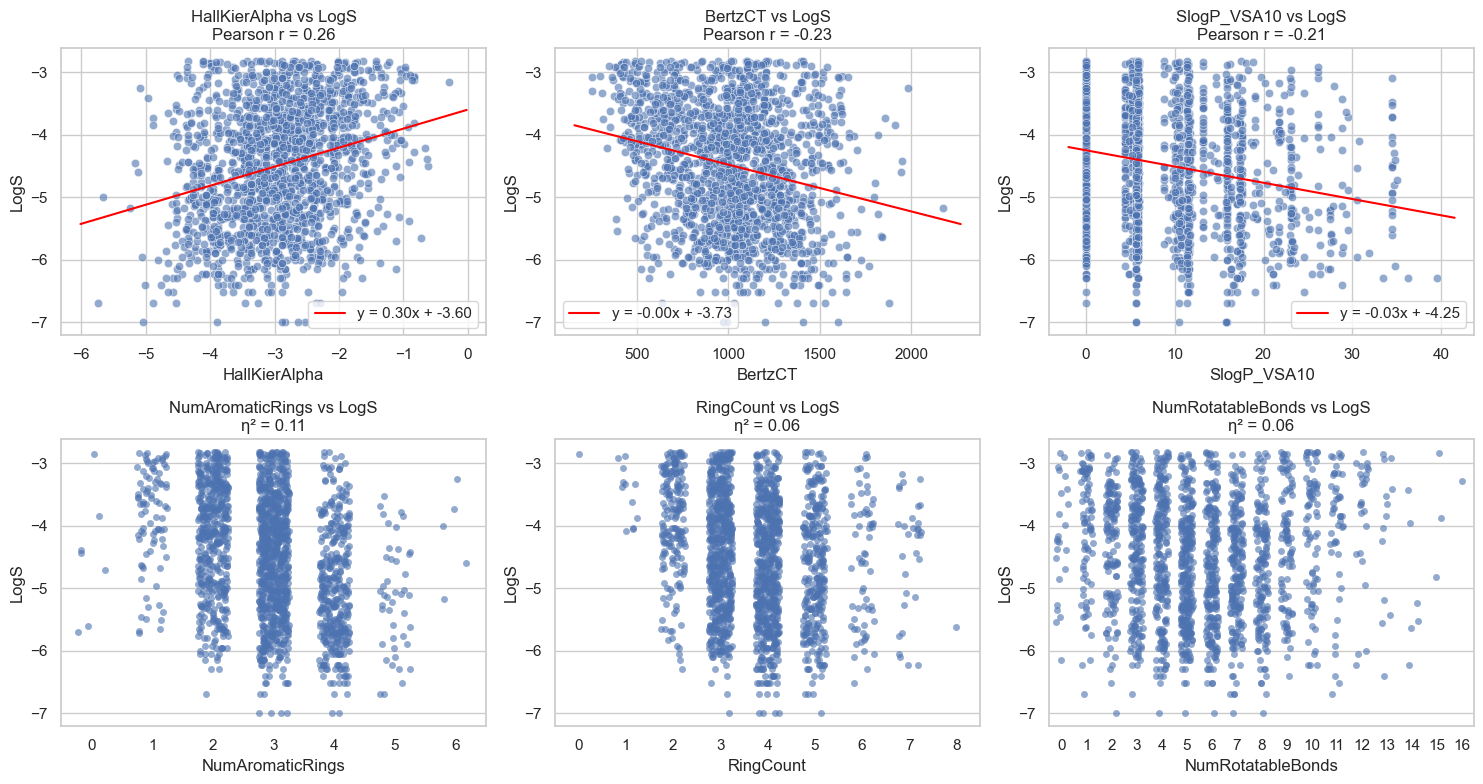

In [7]:
num_plotted_features = 3
# ---- Plotting ----
features_to_plot = top_cont[:3] + top_disc[:num_plotted_features]
n = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (feature, score) in enumerate(features_to_plot):
    ax = axes[i]
    x = X_full[feature]
    y = y_full
    sparsity = x.nunique() / len(x)

    if sparsity > sparsity_threshold and x.dtype.kind in 'bifc':
        # Continuous feature
        sns.scatterplot(x=x, y=y, ax=ax, alpha=0.6)
        slope, intercept = np.polyfit(x, y, deg=1)
        x_vals = np.array(ax.get_xlim())
        y_vals = slope * x_vals + intercept
        ax.plot(x_vals, y_vals, color='red', label=f'y = {slope:.2f}x + {intercept:.2f}')
        label = f'Pearson r = {score:.2f}'

        ax.legend()
    else:
        # Discrete feature
        sns.stripplot(x=x, y=y, ax=ax, jitter=0.25, alpha=0.6)
        label = f'η² = {score:.2f}'

    ax.set_title(f'{feature} vs LogS\n{label}', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('LogS')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# 2. Train test splitting

Before I call my RF model, I need to split my data into train ad test split and set the test split aside until I finish training my model.

I use the `sklearn`'s handy function and I assign 20% of the dataset for testing.

# Molecules in Training set: 1410
# Molecules in Test set: 353


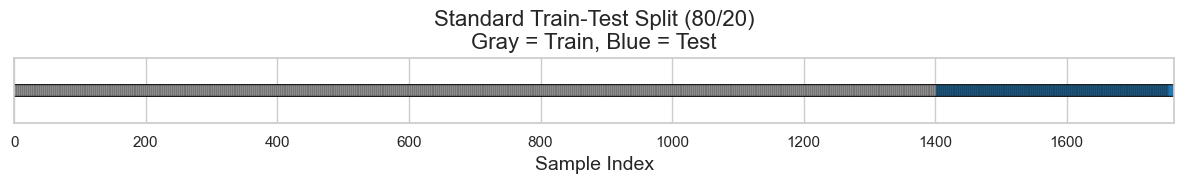

In [8]:
# ---- Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

print("# Molecules in Training set:", len(X_train))
print("# Molecules in Test set:", len(X_test))

# Total number of samples
n_samples = len(X_train) + len(X_test)

# Get positions
x_positions = np.arange(n_samples)
y_positions = np.zeros(n_samples)

# Determine train/test boundaries
n_train = len(X_train)
n_test = len(X_test)

# Create color array
colors = ['lightgray'] * n_train + ['tab:blue'] * n_test

# Plot
fig, ax = plt.subplots(figsize=(12, 2))

# Scatter points (optional – add visual markers)
ax.scatter(x_positions, y_positions, c=colors, marker='s', s=60, edgecolor='k', linewidth=0.3)

# Formatting
ax.set_yticks([])
ax.set_xlim(0, n_samples)
ax.set_xlabel('Sample Index', fontsize=14)
ax.set_title('Standard Train-Test Split (80/20)\nGray = Train, Blue = Test', fontsize=16)
plt.tight_layout()

plt.savefig(os.path.join(images_dir, 'train_test_split.png'))

plt.show()

# 3. Model training (kinda-Random Forest)

`sklearn` is also making life so much easier with its available implementation for RF models. I use the default settings for the parameters of the model.

However, **one thing to note** is that `sklearn` has changed its default setting for the parameter `max_features = 1` in the current version I am using (1.6.1). This is kinda weird for me because RF is based on two concepts
1. Sample bootstrapping with a replacement per tree (i.e., each tree sees a bootstrapped sample of the datasets, making each tree see a different distribution of my values)
2. Feature sampling per split (i.e., at each split in a tree, a feature subset is sampled of the feature space to be the feature pool for this specific split.)

When `max_feature = 1`, this makes all features considered at each single split, which reduces one part of the randomness of the model. Making it "kinda-random forest." HAHAHA... sorry... 👀

I do not know why this decision or how it is gonna affect my training. However, I thought it was worth mentioning.

And currently, I do nothing to change it.

In [9]:
# ---- Train Model ----
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# ---- Predictions & Residuals ----
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

residuals_train = train_preds - y_train
residuals_test = test_preds - y_test

# 4. Residual inspection

After training my model on the training set, testing it on the test set, getting the predictions, and calculating the residuals, I now plot this residual and look at it.

- I show the histogram for the sense of bins frequency
- I plot the KDE for a sense of the distribution shape
- I show the µ line to know where my average is
- I show a boxplot to quickly determine skewness
- I highlight the area that is 1 σ away from my mean because this corresponds to 68% of my errors in a normal distribution (which is not exactly the case here, but I twist it to be nonetheless, hehehe)

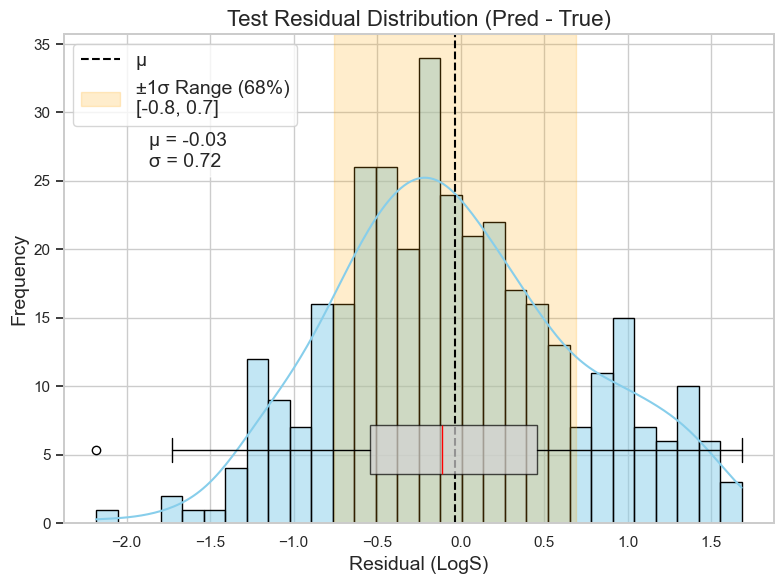

In [10]:
np.random.seed(42)

# Compute mean and std of residuals
x_bar = residuals_test.mean()
s = residuals_test.std()
lower = x_bar - s
upper = x_bar + s

# Plot histogram with KDE
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(residuals_test, bins=30, kde=True, stat='count', color='skyblue', edgecolor='black', ax=ax)

# Vertical line at mean
ax.axvline(x_bar, color='black', linestyle='--', label='μ')

# Highlight ±1σ interval
ax.axvspan(lower, upper, color='orange', alpha=0.2, label=f'±1σ Range (68%)\n[{lower:.1f}, {upper:.1f}]')

# Add text with µ and σ
ax.text(
    0.12, 0.8,
    f'μ = {x_bar:.2f}\nσ = {s:.2f}',
    transform=ax.transAxes,
    verticalalignment='top',
    horizontalalignment='left',
    fontsize=14,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
)

# Overlay horizontal boxplot on secondary y-axis
ax_box = ax.twinx()
ax_box.set_ylim(0, 1)
ax_box.set_xlim(ax.get_xlim())
ax_box.boxplot(residuals_test,
               vert=False,
               positions=[0.15],  # Controls vertical location of boxplot
               widths=0.1,
               patch_artist=True,
               boxprops=dict(facecolor='lightgray', alpha=0.7),
               medianprops=dict(color='red'))
ax_box.set(yticks=[], ylabel='')

# Labels and legend
ax.set_title('Test Residual Distribution (Pred - True)', fontsize=16)
ax.set_xlabel('Residual (LogS)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'train_test_split_performance.png'))
plt.show()


# 5. Estimating distribution parameters

I am still functioning under the assumption of normal distribution for the model's residuals. To construct a normal distribution, one needs to know two parameters:
1. the mean (µ)
2. standard deviation (SD).

I already got a snippet of this distribution's mean and SD using my sample of 353 molecules, but I want to have some confidence when speaking about the true distribution... Ironically enough, just as in real life, confidence emerges when one surrenders to the fact that they cannot pinpoint a single truth and finds peace in speaking with uncertainty!

So, what I can do is to estimate some uncertainty when speaking about the mean and SD of my true distribution.

I have already explained in the last post and notebook how CLT is helping me speak with uncertainty about my mean. But I also showed that I need multiple i.i.d. samples to use CLT. But I only have one sample here (i.e., one test set).

This will call for another simplification of estimating my parameters. A simplification of two assumptions
1. my test set is large enough
2. my test set is representative

Under these two assumptions, there are two ways to approximate my mena and SD with uncertainty (i.e., confidence)

## 1. The analytical approach (parametric)

In this approach, I consult pre-defined equations and tables that were built on the shoulder of the assumptions that we discussed previously.

For estimating the mean, CLT has already told me that it follows a normal distribution. And if I am satisfied with the quality of my test set, I can use its mean and standard deviation to calculate the confidence interval (CI) for the true mean. This will be done using the [t-table](https://www.sjsu.edu/faculty/gerstman/StatPrimer/t-table.pdf) that govern a normal distribution built from a sample of size `n`

In [11]:
# --- Sample statistics ---
alpha = 0.05 # 95% CI
n = len(residuals_test)
sem = s / np.sqrt(n)
t_crit = t.ppf(1 - alpha / 2, df=n - 1)

# --- 95% CI for the mean using t-distribution ---
ci_lower = x_bar - t_crit * sem
ci_upper = x_bar + t_crit * sem

Estimating the standard deviation is a slightly different story as it is known to follow a chi-squared distribution. The below code shows how the distribution shape changes with the change in the sample size (correspoding to the degree of freedom)

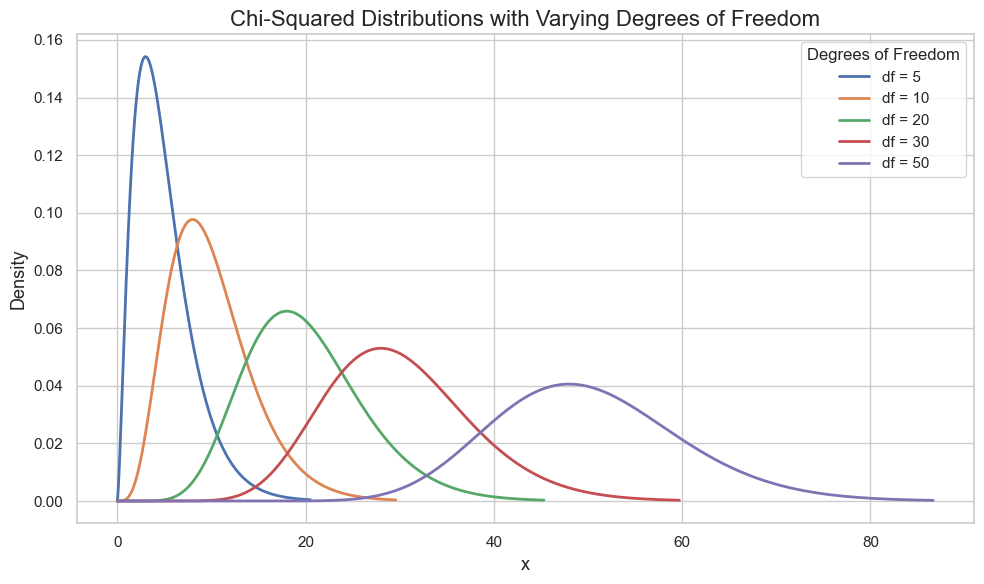

In [12]:
# --- List of degrees of freedom to plot ---
df_list = [5, 10, 20, 30, 50]

# --- Setup plot ---
plt.figure(figsize=(10, 6))

# --- Plot each distribution ---
for df in df_list:
    x = np.linspace(0, chi2.ppf(0.999, df), 500)
    pdf = chi2.pdf(x, df)
    plt.plot(x, pdf, lw=2, label=fr'df = {df}')

# --- Plot formatting ---
plt.title('Chi-Squared Distributions with Varying Degrees of Freedom', fontsize=16)
plt.xlabel('x', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.legend(title='Degrees of Freedom', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'chi_squared.png'))
plt.show()


The ci-squared distribution has [its own table](https://math.arizona.edu/~jwatkins/chi-square-table.pdf) and equation to calculate a CI of certain level.

In [13]:
# Step 1: Sample statistics
df = n - 1
s2 = np.var(residuals_test, ddof=1)  # unbiased sample variance

# Step 2: Chi-squared critical values
alpha = 0.05
chi2_lower = chi2.ppf(1 - alpha / 2, df)
chi2_upper = chi2.ppf(alpha / 2, df)

# Step 3: Confidence interval for variance
var_lower = (df * s2) / chi2_lower
var_upper = (df * s2) / chi2_upper

# Step 4 (optional): Convert to standard deviation
std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

# Output
print(f"Sample variance: {s2:.4f}")
print(f"95% CI for population variance: [{var_lower:.4f}, {var_upper:.4f}]")
print(f"95% CI for population std deviation: [{std_lower:.4f}, {std_upper:.4f}]")


Sample variance: 0.5242
95% CI for population variance: [0.4546, 0.6111]
95% CI for population std deviation: [0.6742, 0.7818]


## 2. The empirical approach—Bootstrapping (non-parametric)

This approach drops the predefined equations and tables and constructs a data-driven distribution to estimate the CIs directly from it.

The idea is to sample `K` samples of size `N` **from the residuals distribution** of the test set. This sampling selects points from the distribution **with replacement** (i.e., a single residual value can appear multiple times in the same sample).

This resampling with replacement ensures that each bootstrapped sample will make a slightly different distribution that will amount to a variation in the constructed distribution.

We can keep track of the distribution for our two parameters, the mean and SD.

In [14]:
# ---- Bootstrap mean and SD from test residuals ----

np.random.seed(42)

n_iterations = 1000
boot_means = []
boot_sds = []

for _ in range(n_iterations):
    sample = np.random.choice(residuals_test, size=len(residuals_test), replace=True)
    boot_means.append(np.mean(sample))
    boot_sds.append(np.std(sample))

boot_means = np.array(boot_means)
boot_sds = np.array(boot_sds)

# ---- Point estimates and confidence intervals ----
mean_residual = np.mean(residuals_test)
sd_residual = np.std(residuals_test)

ci_mean_lower, ci_mean_upper = np.percentile(boot_means, [2.5, 97.5])
std_lower, std_upper = np.percentile(boot_sds, [2.5, 97.5])

# ---- Output ----
print(f"Mean Residual (Sample): {mean_residual:.3f}")
print(f"Bootstrapped 95% CI for Mean: [{ci_mean_lower:.3f}, {ci_mean_upper:.3f}]\n")

print(f"SD of Residuals (Sample): {sd_residual:.3f}")
print(f"Bootstrapped 95% CI for SD: [{std_lower:.3f}, {std_upper:.3f}]")


Mean Residual (Sample): -0.032
Bootstrapped 95% CI for Mean: [-0.108, 0.039]

SD of Residuals (Sample): 0.723
Bootstrapped 95% CI for SD: [0.674, 0.769]


And then extract the corresponding CIs for each parameter.

The distributions and CIs are shown below.

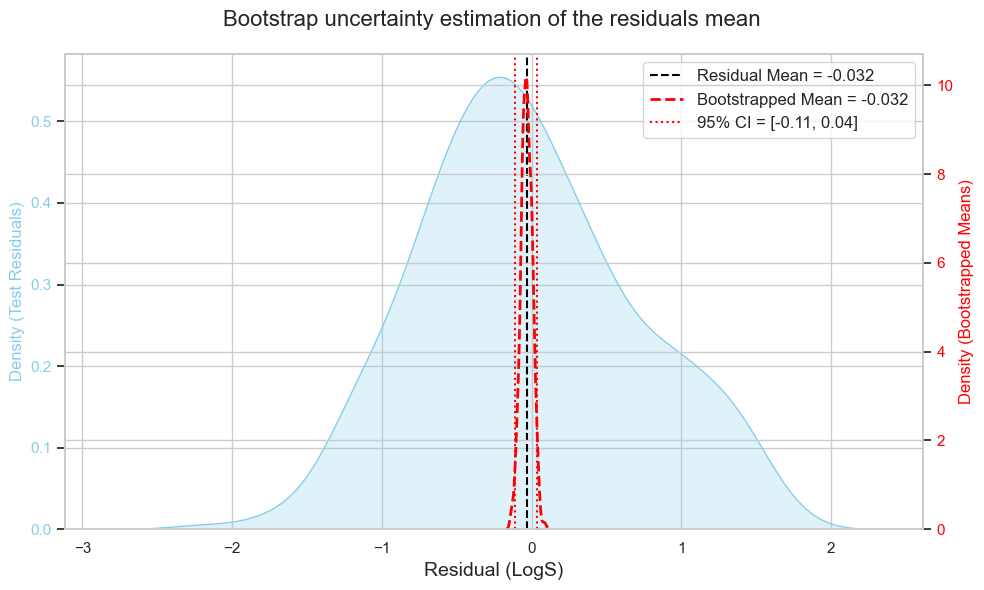

In [15]:
from matplotlib.lines import Line2D

# Compute 95% confidence interval
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

# ---- Plot ----
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Primary axis: Test residual KDE ---
sns.kdeplot(residuals_test, fill=True, color='skyblue', ax=ax1)
ax1.axvline(x_bar, color='black', linestyle='--', linewidth=1.5, label=f'Residual Mean = {x_bar:.3f}')
ax1.set_xlabel('Residual (LogS)', fontsize=14)
ax1.set_ylabel('Density (Test Residuals)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# --- Secondary axis: Bootstrapped KDE ---
ax2 = ax1.twinx()
sns.kdeplot(boot_means, color='red', linestyle='--', linewidth=2,
            fill=False, ax=ax2, label=f'Bootstrapped Mean = {mean_residual:.3f}')
ax2.axvline(ci_lower, color='red', linestyle=':', linewidth=1.5)
ax2.axvline(ci_upper, color='red', linestyle=':', linewidth=1.5)
ax2.set_ylabel('Density (Bootstrapped Means)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Add 95% CI dummy line for legend only ---
ci_label = f'95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]'
ci_dummy_line = Line2D([], [], color='red', linestyle=':', linewidth=1.5, label=ci_label)

# --- Title and legend ---
fig.suptitle('Bootstrap uncertainty estimation of the residuals mean', fontsize=16)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine and add CI label
ax1.legend(
    handles=lines_1 + lines_2 + [ci_dummy_line],
    labels=labels_1 + labels_2 + [ci_label],
    fontsize=12,
    loc='upper right'
)

plt.tight_layout()

plt.savefig(os.path.join(images_dir, 'bootstrap.png'))

plt.show()


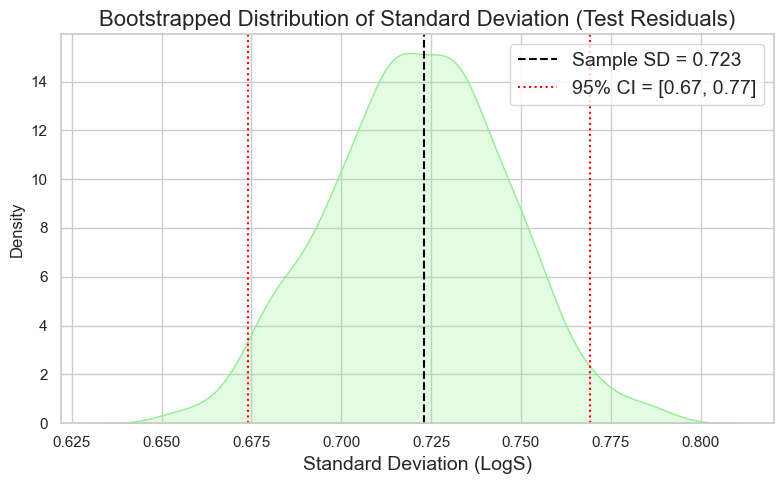

In [16]:
# ---- Plot SD distribution ----
plt.figure(figsize=(8, 5))
sns.kdeplot(boot_sds, fill=True, color='lightgreen')

# Vertical lines
plt.axvline(sd_residual, color='black', linestyle='--', label=f'Sample SD = {sd_residual:.3f}')
plt.axvline(std_lower, color='red', linestyle=':', linewidth=1.5)
plt.axvline(std_upper, color='red', linestyle=':', linewidth=1.5)

# CI label as dummy line (for legend)
from matplotlib.lines import Line2D
ci_label = f'95% CI = [{std_lower:.2f}, {std_upper:.2f}]'
ci_dummy_line = Line2D([], [], color='red', linestyle=':', linewidth=1.5, label=ci_label)

# Legend and labels
plt.title('Bootstrapped Distribution of Standard Deviation (Test Residuals)', fontsize=16)
plt.xlabel('Standard Deviation (LogS)', fontsize=14)
plt.ylabel('Density', fontsize=12)
plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [ci_dummy_line], fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'bootstrap_sd.png'))
plt.show()


# 6. Plotting the "true" performance

With my estimated ranges, I do not have a single value for my mean or SD, but rather a range. So, instead of building a single distribution, I build three!
1. The best case with µ = 0 and σ = lower bound
2. The worst case where the model underestimates the true value (µ = lower bound, σ = upper bound)
3. The worst case where the model overestimates the true value (µ = upper bound, σ = upper bound)

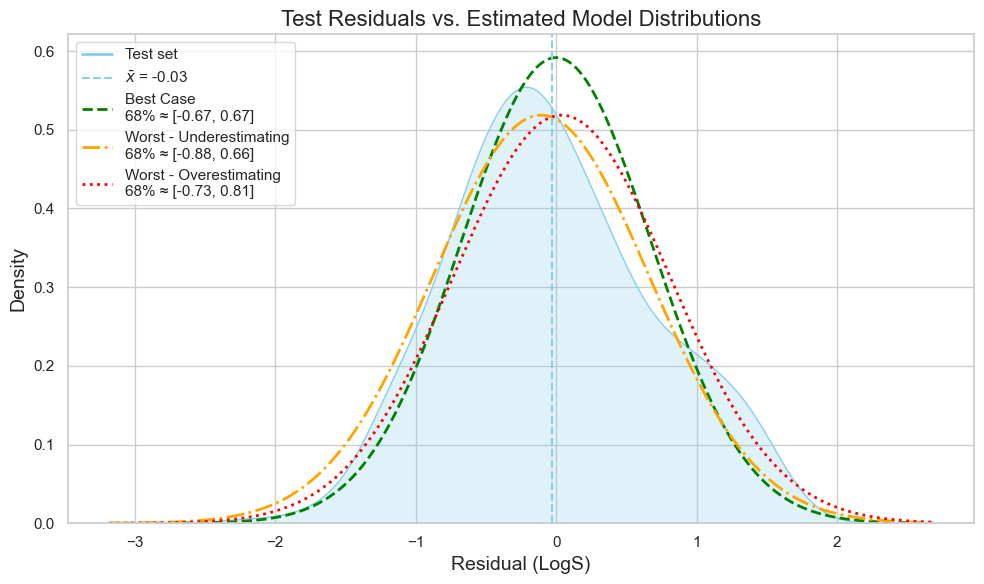

In [17]:
# --- Inputs ---
best_mean = 0
alpha = 0.05  # for 95% confidence interval

# --- x-range ---
x_vals = np.linspace(residuals_test.min() - 1, residuals_test.max() + 1, 500)

# --- Distributions ---
best_pdf = norm.pdf(x_vals, loc=best_mean, scale=std_lower)
worst_low_pdf = norm.pdf(x_vals, loc=ci_lower, scale=std_upper)
worst_high_pdf = norm.pdf(x_vals, loc=ci_upper, scale=std_upper)

# --- Plot ---
plt.figure(figsize=(10, 6))

# KDE of actual residuals
sns.kdeplot(residuals_test, fill=True, color='skyblue')

# Hypothetical model curves
plt.plot(x_vals, best_pdf, color='green', linestyle='--', linewidth=2)
plt.plot(x_vals, worst_low_pdf, color='orange', linestyle='-.', linewidth=2)
plt.plot(x_vals, worst_high_pdf, color='red', linestyle=':', linewidth=2)

# Sample mean vertical line
plt.axvline(x_bar, color='skyblue', linestyle='--', linewidth=1.5)

# --- Legend construction ---
handles = []
labels = []

# Test set
handles.append(Line2D([], [], color='skyblue', linewidth=2))
labels.append('Test set')
handles.append(Line2D([], [], color='skyblue', linestyle='--', linewidth=1.5))
labels.append(f'$\\bar{{x}}$ = {x_bar:.2f}')

# Best Case
handles.append(Line2D([], [], color='green', linestyle='--', linewidth=2))
labels.append(f'Best Case\n68% ≈ [{(best_mean - std_lower):.2f}, {(best_mean + std_lower):.2f}]')

# Worst Case 1
handles.append(Line2D([], [], color='orange', linestyle='-.', linewidth=2))
labels.append(f'Worst - Underestimating\n68% ≈ [{(ci_lower - std_upper):.2f}, {(ci_lower + std_upper):.2f}]')

# Worst Case 2
handles.append(Line2D([], [], color='red', linestyle=':', linewidth=2))
labels.append(f'Worst - Overestimating\n68% ≈ [{(ci_upper - std_upper):.2f}, {(ci_upper + std_upper):.2f}]')

# Final legend
plt.legend(handles, labels, fontsize=11, loc='upper left')

# Labels and title
plt.title('Test Residuals vs. Estimated Model Distributions', fontsize=16)
plt.xlabel('Residual (LogS)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.tight_layout()

# Optional: save
plt.savefig(os.path.join(images_dir, 'estimated_distributions.png'))
plt.show()

# Wrapping Up

- With small datasets, the **battle for the true distribution** is often lost.
  - The goal shifts to **making a truce** and quantifying what can still be learned.
- One needs to identify their assumption on the true distribution, to identify which parameters to estimate and how
  - For a normal distribution, one needs to estimate µ and σ.
  - Estimation can be done analytically (with assumptions) or empirically (with relaxed assumptions).
- A single true distribution may not be the way, but rather, multiple distribution for the best and worst cases based on CIs.
- When one is limited in quantity, one needs to compensate with quality and rigor.